In [90]:
# Import required libraries
import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns            # Advanced visualization

# For better plot style
sns.set(style="whitegrid")

In [78]:
# Load dataset
df = pd.read_csv('sales_data.csv')

# Show first 5 rows
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [79]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.columns)

Index(['product_id', 'sale_date', 'sales_rep', 'region', 'sales_amount',
       'quantity_sold', 'product_category', 'unit_cost', 'unit_price',
       'customer_type', 'discount', 'payment_method', 'sales_channel',
       'region_and_sales_rep'],
      dtype='object')


In [80]:
print(df.isnull().sum())

product_id              0
sale_date               0
sales_rep               0
region                  0
sales_amount            0
quantity_sold           0
product_category        0
unit_cost               0
unit_price              0
customer_type           0
discount                0
payment_method          0
sales_channel           0
region_and_sales_rep    0
dtype: int64


In [81]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [82]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [83]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

In [84]:
df['month'] = df['sale_date'].dt.month
df['year'] = df['sale_date'].dt.year

In [85]:
total_revenue = df['sales_amount'].sum()
total_orders = len(df)
avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 5019265.2299999995
Total Orders: 1000
Average Order Value: 5019.265229999999


In [91]:
# Monthly Sales Trend
sales_trend = df.groupby('month')['sales_amount'].sum()

# Top Products
top_products = df.groupby('product_id')['sales_amount'].sum().sort_values(ascending=False).head(5)

# Region Sales
region_sales = df.groupby('region')['sales_amount'].sum()

# Category Sales
category_sales = df.groupby('product_category')['sales_amount'].sum()

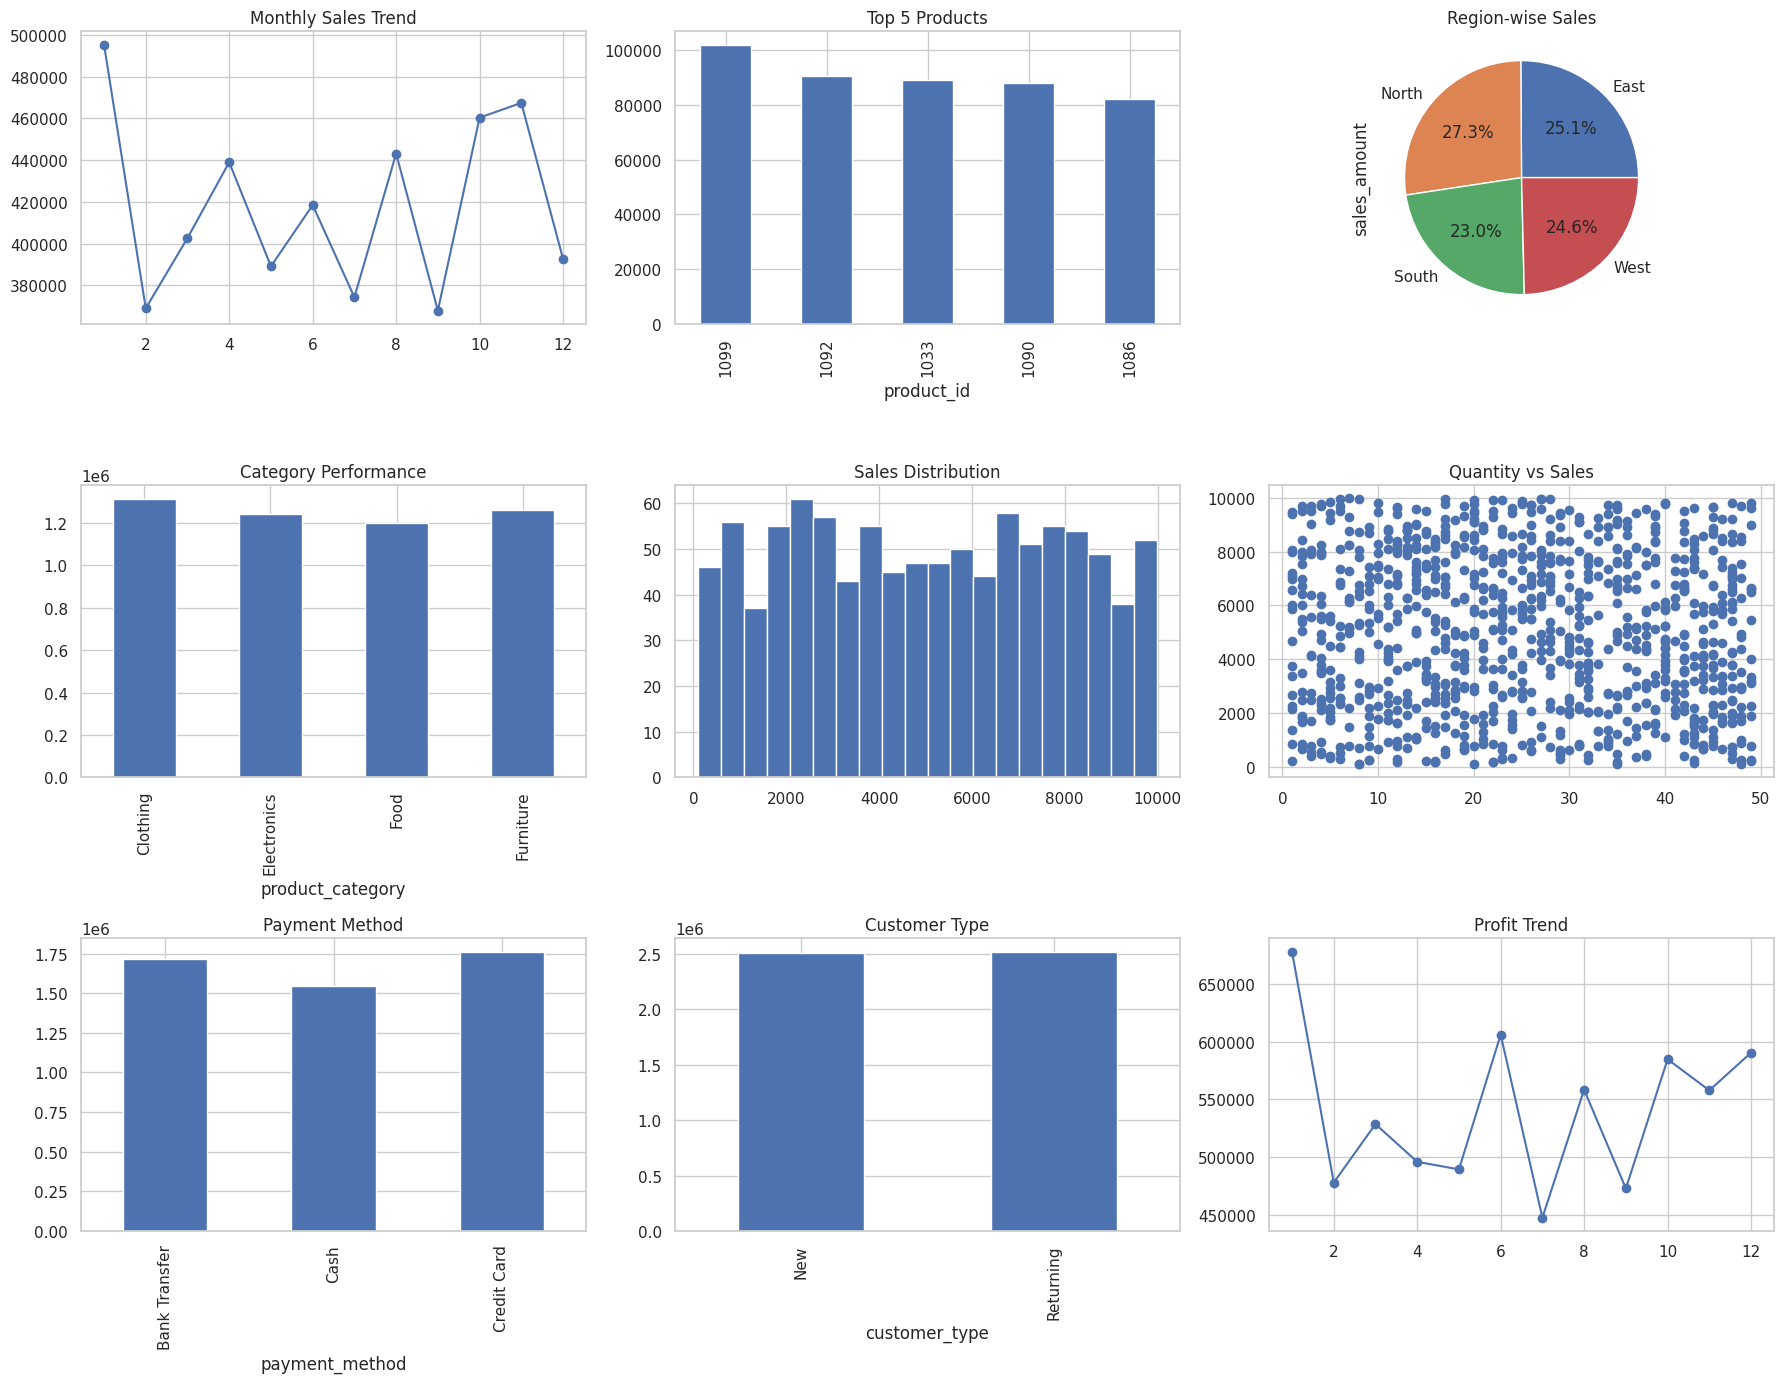

<Figure size 640x480 with 0 Axes>

In [87]:
# ==========================================
# FINAL PROFESSIONAL DASHBOARD
# ==========================================

fig, axes = plt.subplots(3, 3, figsize=(18,14))

# 1️⃣ Monthly Sales Trend
monthly_sales = df.groupby('month')['sales_amount'].sum()
axes[0,0].plot(monthly_sales.index, monthly_sales.values, marker='o')
axes[0,0].set_title("Monthly Sales Trend")

# 2️⃣ Top Products
top_products = df.groupby('product_id')['sales_amount'].sum().sort_values(ascending=False).head(5)
top_products.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Top 5 Products")

# 3️⃣ Region Sales
region_sales = df.groupby('region')['sales_amount'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', ax=axes[0,2])
axes[0,2].set_title("Region-wise Sales")

# 4️⃣ Category Sales
category_sales = df.groupby('product_category')['sales_amount'].sum()
category_sales.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Category Performance")

# 5️⃣ Sales Distribution
axes[1,1].hist(df['sales_amount'], bins=20)
axes[1,1].set_title("Sales Distribution")

# 6️⃣ Quantity vs Sales
axes[1,2].scatter(df['quantity_sold'], df['sales_amount'])
axes[1,2].set_title("Quantity vs Sales")

# 7️⃣ Payment Method Sales
payment_sales = df.groupby('payment_method')['sales_amount'].sum()
payment_sales.plot(kind='bar', ax=axes[2,0])
axes[2,0].set_title("Payment Method")

# 8️⃣ Customer Type Sales
customer_sales = df.groupby('customer_type')['sales_amount'].sum()
customer_sales.plot(kind='bar', ax=axes[2,1])
axes[2,1].set_title("Customer Type")

# 9️⃣ Profit Trend (Advanced)
df['profit'] = (df['unit_price'] - df['unit_cost']) * df['quantity_sold']
profit_trend = df.groupby('month')['profit'].sum()
axes[2,2].plot(profit_trend.index, profit_trend.values, marker='o')
axes[2,2].set_title("Profit Trend")

# Layout adjustment
plt.tight_layout()

# Show dashboard
plt.show()

# Save dashboard (for portfolio)
plt.savefig("final_dashboard.png", dpi=300)